<a href="https://colab.research.google.com/github/starsyntaxx/tracy_hackathon/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
import zipfile
import os

# Upload file from your laptop
uploaded = files.upload()

# Get uploaded filename
zip_file = list(uploaded.keys())[0]

# Create extraction folder
extract_folder = "dataset"

# Unzip the file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Dataset extracted to: {os.path.abspath(extract_folder)}")

# View extracted files
for root, dirs, files in os.walk(extract_folder):
    for file in files[:5]:  # show first few files
        print(os.path.join(root, file))

Saving data-20260615T111051Z-3-001.zip to data-20260615T111051Z-3-001.zip
Dataset extracted to: /content/dataset
dataset/data/contact_tracing.csv
dataset/data/vitals.csv
dataset/data/mobility.csv


In [6]:
import pandas as pd

In [7]:
# Read the CSV file
mobility = pd.read_csv("dataset/data/mobility.csv")
vitals = pd.read_csv("dataset/data/vitals.csv")
contacts = pd.read_csv("dataset/data/contact_tracing.csv")

In [15]:
contacts['rssi'].value_counts()

,count
rssi,
-1,72858
12,29717
8,5931
7,3940
11,2746
6,2071
-5,718
4,352
-11,324


In [16]:
vitals.head(10)

,device_id,date,time,latitude,longitude,geohash,temperature,temp_status,heartbeat,hr_status,movement,battery
0,D009,2024-05-13,06:56:50,7.304037,5.138820,s179sctvp,31.0,low,96.0,normal,0.0,100.0
1,D009,2024-05-13,06:57:00,7.303961,5.138694,s179sctus,31.0,low,110.0,high,0.0,100.0
2,D009,2024-05-13,06:57:20,7.303785,5.138458,s179sctew,30.0,low,76.0,normal,1.0,100.0
3,D009,2024-05-13,07:16:00,7.304892,5.132193,s179scc4h,34.0,low,49.0,low,0.0,100.0
4,D009,2024-05-13,07:17:25,7.304774,5.132284,s179scc1q,34.0,low,43.0,low,0.0,100.0
5,D009,2024-05-13,07:17:40,7.304631,5.132177,s179scc0s,34.0,low,50.0,low,0.0,100.0
6,D009,2024-05-13,07:17:55,7.304082,5.132130,s179sc9j7,34.0,low,38.0,low,0.0,100.0
7,D009,2024-05-13,07:18:00,7.303935,5.132137,s179sc9he,34.0,low,38.0,low,0.0,100.0
8,D009,2024-05-13,07:18:06,7.303546,5.132148,s179sc945,34.0,low,51.0,low,0.0,100.0
9,D009,2024-05-13,07:18:11,7.303323,5.132174,s179sc90u,34.0,low,51.0,low,0.0,100.0


In [4]:
contacts.head()

,user_id,date,time,latitude,longitude,geohash,mac,rssi,proximity
0,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13941,-1,unscored
1,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13227,8,close
2,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D21917,-1,unscored
3,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D19180,-1,unscored
4,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D05480,7,close


In [25]:
superspreaders = contacts.loc[(contacts['rssi'] > 5 )]

In [28]:
superspreaders.head()

,user_id,date,time,latitude,longitude,geohash,mac,rssi,proximity
1,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13227,8,close
4,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D05480,7,close
5,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D13423,7,close
6,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D07028,12,close
10,U003,2023-10-20,06:12:43,5.375526,6.998862,s0uyx686t,D05480,7,close


In [35]:
import plotly.express as px
superspreaders['date'] = pd.to_datetime(superspreaders['date'])

# 4. Group by User and Date to find the total close contacts per day
df_daily = superspreaders.groupby(['user_id', 'date'])['proximity'].max().reset_index()

# 5. Sort the dates so the line draws smoothly from left to right
df_daily = df_daily.sort_values('date')

# 6. Plot the clean Line Graph
fig_line = px.line(
    df_daily,
    x='date',
    y='proximity',
    color='user_id',
    title='Super-Spreader Activity Timeline: Daily Close Contact Trends',
    labels={
        'date': 'Timeline (Dates)',
        'proximity': 'Daily Close Contacts Count',
        'user_id': 'Tracked Super-Spreader'
    },
    color_discrete_map={
        'U021': '#636EFA',  # Blue line
        'U057': '#00CC96',  # Green line
        'U022': '#EF553B'   # Red/Orange line
    },
    template='plotly_white'
)

# Polishing the chart layout to make it crisp and highly presentable
fig_line.update_traces(mode='lines+markers', marker=dict(size=4))
fig_line.update_layout(
    hovermode='x unified',
    legend_title_text='Human Vector ID'
)

# Show the line chart
fig_line.show()

/tmp/ipykernel_9098/841031992.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [26]:
superspreaders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44761 entries, 1 to 119336
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    44761 non-null  object 
 1   date       44761 non-null  object 
 2   time       44761 non-null  object 
 3   latitude   44761 non-null  float64
 4   longitude  44761 non-null  float64
 5   geohash    44761 non-null  object 
 6   mac        44761 non-null  object 
 7   rssi       44761 non-null  int64  
 8   proximity  44761 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 3.4+ MB


In [27]:
superspreaders['proximity'].value_counts()

,count
proximity,
close,44675
very close,86


In [ ]:
#We realised a skewed update in the dataset, as some individuals are higher superspreaders than the others

# Count pings per user_id
ping_counts = df_contact['user_id'].value_counts()

# Display the top 10 most frequent users (super-contactors)
print("Top 10 users with the highest detection pings:")
print(ping_counts.head(10))

Top 10 users with the highest detection pings:
user_id
U021    16223
U057    15285
U022    13075
U030     8575
U020     7420
U041     5585
U023     5291
U008     4497
U061     4234
U025     2985
Name: count, dtype: int64


In [ ]:
df_contact['rssi'].unique()

array([ -1,   8,   7,  12,   6,   9,  -5, -21,   4,  11,  24, -11,   2,
       -10,   1,   0,   5, -15, -20,   3,  26])

In [ ]:
df_contact['geohash'].nunique()

6721

In [ ]:
df_contact['latitude'].nunique()

12227

In [ ]:
df_contact['rssi'].value_counts()

,count
rssi,
-1,72858
12,29717
8,5931
7,3940
11,2746
6,2071
-5,718
4,352
-11,324


In [ ]:
df_filtered = df_contact[df_contact['rssi'] >= 5]

df_filtered.head()

,user_id,date,time,latitude,longitude,geohash,mac,rssi,proximity,timestamp
1,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13227,8,close,2023-10-19 18:06:01
4,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D05480,7,close,2023-10-20 06:12:13
5,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D13423,7,close,2023-10-20 06:12:13
6,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D07028,12,close,2023-10-20 06:12:13
10,U003,2023-10-20,06:12:43,5.375526,6.998862,s0uyx686t,D05480,7,close,2023-10-20 06:12:43


In [ ]:

df_filtered['mac'].nunique()

8109

In [ ]:
print("Original shape:", df_mobility.shape)
print("Filtered shape:", df_filtered.shape)

Original shape: (50737, 11)
Filtered shape: (44932, 9)


stimullaate network graph

In [ ]:
# combine date + time into timestamp
df_contact['timestamp'] = pd.to_datetime(df_contact['date'] + ' ' + df_contact['time'])

df_contact.head()

,user_id,date,time,latitude,longitude,geohash,mac,rssi,proximity,timestamp
0,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13941,-1,unscored,2023-10-19 18:06:01
1,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D13227,8,close,2023-10-19 18:06:01
2,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D21917,-1,unscored,2023-10-19 18:06:01
3,U002,2023-10-19,18:06:01,7.680377,6.418345,s1kedn1tq,D19180,-1,unscored,2023-10-19 18:06:01
4,U003,2023-10-20,06:12:13,5.374891,6.998611,s0uyx62pp,D05480,7,close,2023-10-20 06:12:13


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [ ]:
G = nx.Graph()

for mac, group in df.groupby('mac'):
    users = group['user_id'].unique()

    for i in range(len(users)):
        for j in range(i+1, len(users)):
            u1, u2 = users[i], users[j]

            if G.has_edge(u1, u2):
                G[u1][u2]['weight'] += 1
            else:
                G.add_edge(u1, u2, weight=1)

In [ ]:
def rssi_weight(rssi):
    return max(0, rssi + 100) / 100  # normalize

df_contact['rssi_w'] = df_contact['rssi'].apply(rssi_weight)

In [ ]:
exposure = df.groupby('user_id').agg({
    'rssi_w': 'sum',
    'mac': 'count'
}).rename(columns={'mac': 'frequency'})

exposure['exposure_score'] = (
    exposure['rssi_w'] * 0.7 +
    exposure['frequency'] * 0.3
)

exposure.sort_values('exposure_score', ascending=False).head()

,rssi_w,frequency,exposure_score
user_id,,,
U021,16731.08,16223,16578.656
U057,15773.18,15285,15626.726
U022,13491.82,13075,13366.774
U030,8925.71,8575,8820.497
U020,7641.79,7420,7575.253


In [ ]:
degree = nx.degree_centrality(G)

betweenness = nx.betweenness_centrality(G, weight='weight')

superspreader_score = {
    n: degree[n] + betweenness[n]
    for n in G.nodes()
}

sorted(superspreader_score.items(), key=lambda x: x[1], reverse=True)[:10]

[('U061', 0.41170940170940173),
 ('U058', 0.35337606837606844),
 ('U021', 0.2903846153846154),
 ('U020', 0.26987179487179486),
 ('U011', 0.24102564102564103),
 ('U056', 0.23891025641025643),
 ('U057', 0.23715811965811967),
 ('U008', 0.2153846153846154),
 ('U051', 0.20196581196581198),
 ('U022', 0.1903846153846154)]

In [ ]:
hotspots = df.groupby('geohash').size().reset_index(name='count')

hotspots = hotspots.sort_values('count', ascending=False)
hotspots.head(10)

,geohash,count
2435,s179sc7xm,1932
2111,s179mpvj4,1324
2862,s179scjmw,487
2857,s179scjmr,456
2856,s179scjmq,443
6187,s47dww613,382
2864,s179scjmy,360
2903,s179scjt2,358
2865,s179scjmz,345
2853,s179scjmm,333


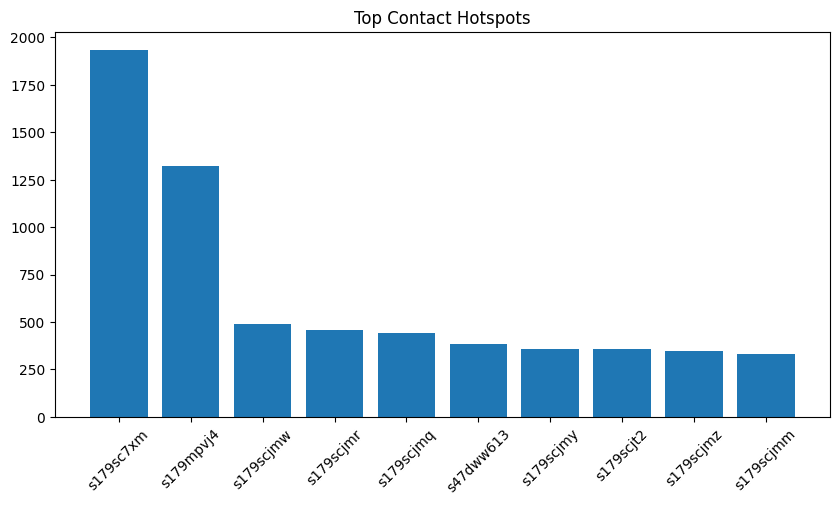

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(hotspots['geohash'][:10], hotspots['count'][:10])
plt.xticks(rotation=45)
plt.title("Top Contact Hotspots")
plt.show()

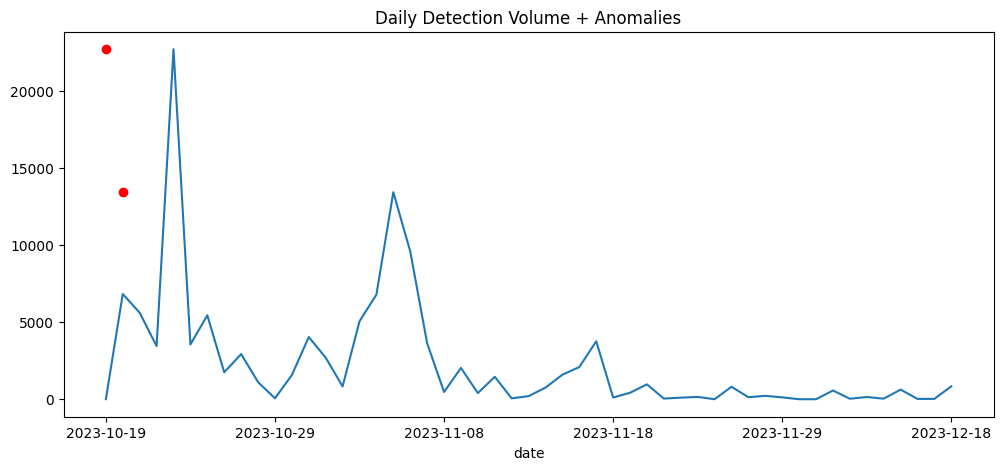

In [ ]:
daily = df.groupby(df['date']).size()

mean = daily.mean()
std = daily.std()

anomalies = daily[(daily > mean + 2*std)]

daily.plot(figsize=(12,5))
plt.scatter(anomalies.index, anomalies.values, color='red')
plt.title("Daily Detection Volume + Anomalies")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

features = exposure[['exposure_score', 'frequency']]

kmeans = KMeans(n_clusters=3, random_state=42)
exposure['risk_cluster'] = kmeans.fit_predict(features)

exposure.head()

,rssi_w,frequency,exposure_score,risk_cluster
user_id,,,,
U001,173.24,173,173.168,2
U002,4.05,4,4.035,2
U003,569.54,548,563.078,2
U004,1.08,1,1.056,2
U005,34.11,33,33.777,2


In [ ]:
import random

def simulate_spread(G, patient_zero, steps=3):
    infected = set([patient_zero])
    current = set([patient_zero])

    for _ in range(steps):
        new = set()

        for node in current:
            for neighbor in G.neighbors(node):
                if neighbor not in infected:

                    weight = G[node][neighbor]['weight']
                    prob = min(1, weight * 0.1)

                    if random.random() < prob:
                        new.add(neighbor)

        infected.update(new)
        current = new

    return infected

simulate_spread(G, list(G.nodes())[0])

{'U007',
 'U008',
 'U011',
 'U012',
 'U020',
 'U021',
 'U022',
 'U023',
 'U024',
 'U026',
 'U033',
 'U035'}

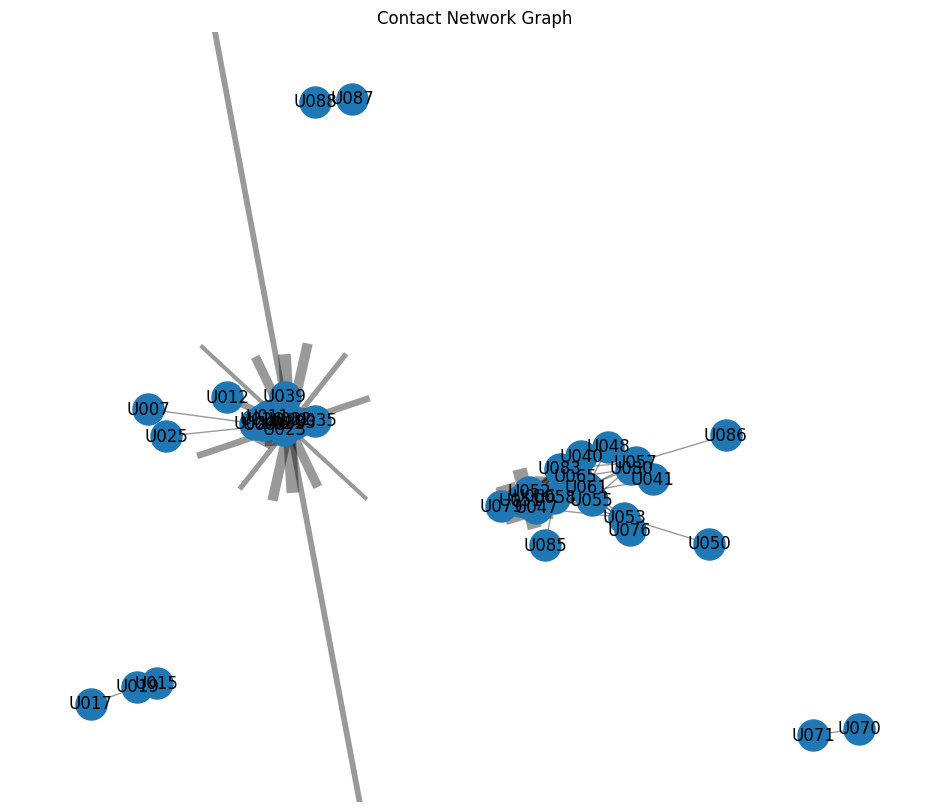

In [ ]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(G)

weights = [G[u][v]['weight'] for u,v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=500)
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.4)
nx.draw_networkx_labels(G, pos)

plt.title("Contact Network Graph")
plt.axis("off")
plt.show()

In [ ]:
df_contact['geohash'].nunique()

6721

VERIFICATION OF HYPOTHESES

In [9]:
# 1. Isolate instances of verified close contacts from the early wave
# We filter for explicit 'close' proximity classifications
close_interactions = contacts[contacts['proximity'] == 'close'].copy()

# 2. Extract total close contact counts and exposure summaries per user from mobility logs
user_risk_profiles = mobility.groupby('user_id').agg(
    total_close_contacts=('close_contacts', 'max'),
    peak_exposure_score=('exposure_score', 'max')
).reset_index()

# 3. Define the Vitals Health Status Baseline (May Wave)
# We find which devices remained completely healthy (No high heart rate, no high temp alerts)
vitals['has_health_alert'] = (vitals['hr_status'] == 'high') | (vitals['temp_status'] == 'high')

device_health_summary = vitals.groupby('device_id').agg(
    total_alerts=('has_health_alert', 'sum'),
    max_heartbeat=('heartbeat', 'max'),
    max_temp=('temperature', 'max')
).reset_index()

# Isolate completely resilient or uninfected devices
healthy_devices = device_health_summary[device_health_summary['total_alerts'] == 0]

print("=== VERIFYING PROXIMITY WITHOUT TRANSMISSION ===")
print(f"Total tracking devices that remained completely asymptomatic in May: {len(healthy_devices)}")
print(healthy_devices.head())

=== VERIFYING PROXIMITY WITHOUT TRANSMISSION ===
Total tracking devices that remained completely asymptomatic in May: 8
  device_id  total_alerts  max_heartbeat  max_temp
0      D001             0           80.0      34.0
4      D005             0           60.0      36.0
5      D006             0          100.0      32.0
6      D007             0           59.0      31.0
9      D010             0           79.0      36.0


In [12]:
healthy_devices.value_counts()

,,,,count
device_id,total_alerts,max_heartbeat,max_temp,
D001,0,80.0,34.0,1
D005,0,60.0,36.0,1
D006,0,100.0,32.0,1
D007,0,59.0,31.0,1
D010,0,79.0,36.0,1
D013,0,94.0,37.0,1
D016,0,80.0,32.0,1
D017,0,80.0,35.0,1


In [13]:
sedentary_vitals = vitals[vitals['movement'] == 0.0].copy()
fig3 = px.scatter(
    sedentary_vitals,
    x="heartbeat",
    y="temperature",
    color="hr_status",
    size="battery",
    title="Visualisation 3: Physiological Uncoupling (Stationary Tachycardia Profiles)",
    labels={"heartbeat": "Resting Heart Rate (BPM)", "temperature": "Core Thermal Tracking (°C)"},
    color_discrete_map={'normal': '#00CC96', 'high': '#EF553B', 'low': '#AB63FA'},
    template="plotly_white"
)

In [30]:
fig3.show()

In [14]:
top_ping_users = contacts['user_id'].value_counts().head(15).reset_index()
top_ping_users.columns = ['user_id', 'total_pings']
fig4 = px.bar(
    top_ping_users,
    x="user_id",
    y="total_pings",
    color="total_pings",
    title="Visualisation 4: Infrastructure Anchors (Top Cumulative Exposure Profiles)",
    labels={"user_id": "Tracked User Identifier", "total_pings": "Total Captured Detection Logs"},
    color_continuous_scale=px.colors.sequential.Plasma,
    template="plotly_white"
)

In [31]:
fig4.show()

In [17]:
mobility.head()

,user_id,date,time,latitude,longitude,geohash,has_contact,exposure_score,daily_exposure,total_detections,close_contacts
0,U023,2024-01-29,01:00:47,7.841960,9.776408,s1quw7wfw,False,41.0,20.5,43.0,13.0
1,U023,2024-01-29,01:00:57,7.838611,9.776060,s1quw6yxn,False,41.0,20.5,43.0,13.0
2,U023,2024-01-29,01:02:11,7.837940,9.776060,s1quw6yeq,False,41.0,20.5,43.0,13.0
3,U023,2024-01-29,01:03:06,7.839316,9.780533,s1quwe1gq,False,41.0,20.5,43.0,13.0
4,U023,2024-01-29,04:12:41,7.839060,9.781374,s1quwe49f,False,41.0,20.5,43.0,13.0


In [20]:
mobility['datetime'] = pd.to_datetime(mobility['date'] + ' ' + mobility['time'])

In [23]:
mobility['week'] = mobility['datetime'].dt.to_period('W').astype(str)

In [10]:
from sklearn.cluster import DBSCAN
import plotly.express as px
import numpy as np

# 1. Load and isolate active vitals anomalies
vitals['is_anomaly'] = (vitals['hr_status'] == 'high') | (vitals['temp_status'] == 'high')
anomaly_data = vitals[vitals['is_anomaly'] == True].dropna(subset=['latitude', 'longitude']).copy()

# 2. Convert Lat/Lon to Radians for Haversine metric (Gives accurate real-world distance tracking)
coords = np.radians(anomaly_data[['latitude', 'longitude']].values)

# 3. Execute DBSCAN: eps represent ~100 meters in radians, min_samples requires 5 nearby alerts
db = DBSCAN(eps=0.0001, min_samples=5, metric='haversine')
anomaly_data['cluster_label'] = db.fit_predict(coords)

print(f"Isolated {anomaly_data['cluster_label'].nunique() - 1} distinct high-risk epidemiological clusters.")

# 4. Plotly Mapbox Canvas
fig_clusters = px.scatter_mapbox(
    anomaly_data,
    lat="latitude",
    lon="longitude",
    color=anomaly_data['cluster_label'].astype(str),
    hover_name="device_id",
    zoom=13,
    mapbox_style="carto-positron",
    title="Epidemiological Clustering: DBSCAN Mapping of Localized Vitals Anomalies"
)
fig_clusters.show()

Isolated 2 distinct high-risk epidemiological clusters.


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate raw metrics to profile each unique user profile
user_profiles = mobility.groupby('user_id').agg({
    'exposure_score': 'max',
    'total_detections': 'max',
    'close_contacts': 'sum'
}).reset_index()

# Scale features to prevent metrics with large scales from dominating the algorithm
scaler = StandardScaler()
scaled_features = scaler.fit_transform(user_profiles[['exposure_score', 'total_detections', 'close_contacts']])

# Group into 3 distinct operational public health personas
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
user_profiles['behavior_cluster'] = kmeans.fit_predict(scaled_features)

fig_behavior = px.scatter(
    user_profiles,
    x="exposure_score",
    y="close_contacts",
    color=user_profiles['behavior_cluster'].astype(str),
    size="total_detections",
    hover_name="user_id",
    title="Behavioral Typology Clustering: Classifying Community Transmission Personas",
    labels={"exposure_score": "Peak Individual Exposure Index", "close_contacts": "Cumulative Close Encounters"}
)
fig_behavior.show()